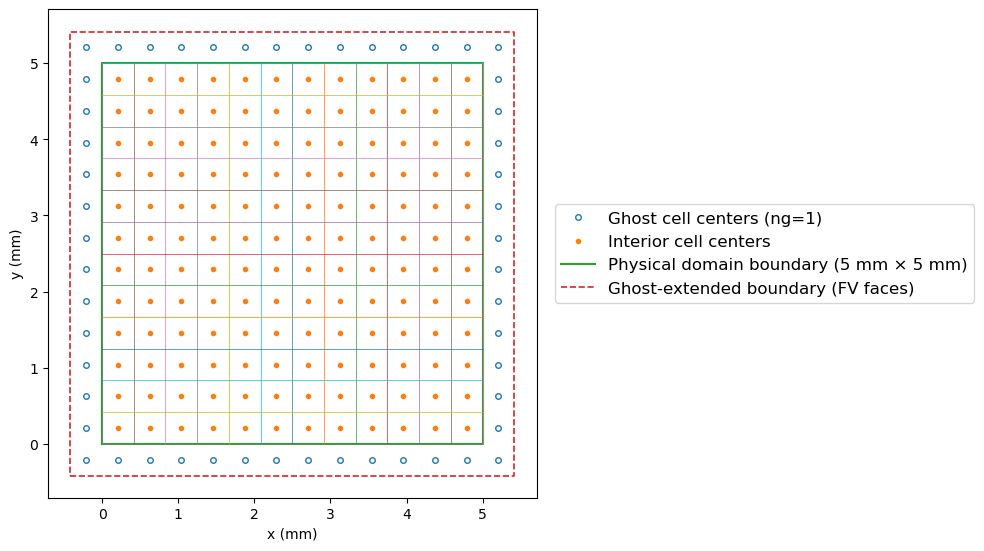

In [3]:
#!/usr/bin/env python3
"""
plot_mesh_with_ghosts.py

Creates a representative 2D Cartesian finite-volume mesh for a 5 mm × 5 mm domain.
Plots:
- Interior cell centers (i = 0..nx-1, j = 0..ny-1)
- Ghost cell centers (one layer around the domain)
- Physical domain boundary
- Ghost-extended boundary

Units: meters internally, axes labeled in mm for readability.
"""

from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt


def plot_mesh_with_ghosts(
    nx: int = 10,
    ny: int = 10,
    Lx: float = 5e-3,
    Ly: float = 5e-3,
    ng: int = 1,
    show_grid_lines: bool = True,
) -> None:
    """
    nx, ny: number of interior control volumes in x and y
    Lx, Ly: physical domain lengths (meters)
    ng: number of ghost layers (typical: 1 or 2)
    """

    if nx <= 0 or ny <= 0:
        raise ValueError("nx and ny must be positive.")
    if ng < 0:
        raise ValueError("ng must be >= 0.")
    if Lx <= 0 or Ly <= 0:
        raise ValueError("Lx and Ly must be positive.")

    dx = Lx / nx
    dy = Ly / ny

    # -------------------------------------------------------------------------
    # Cell-center coordinates
    # Interior indices: i = 0..nx-1, j = 0..ny-1
    # Ghost-extended indices: i = -ng..nx-1+ng, j = -ng..ny-1+ng
    # Cell center: x_i = (i + 0.5)*dx
    # -------------------------------------------------------------------------
    i_all = np.arange(-ng, nx + ng)
    j_all = np.arange(-ng, ny + ng)

    x_all = (i_all + 0.5) * dx
    y_all = (j_all + 0.5) * dy

    X_all, Y_all = np.meshgrid(x_all, y_all, indexing="xy")  # shape (ny+2ng, nx+2ng)

    # Mask for interior vs ghost points
    I_all, J_all = np.meshgrid(i_all, j_all, indexing="xy")
    interior_mask = (I_all >= 0) & (I_all <= nx - 1) & (J_all >= 0) & (J_all <= ny - 1)
    ghost_mask = ~interior_mask

    # -------------------------------------------------------------------------
    # Boundaries (in meters)
    # Physical domain: [0, Lx] × [0, Ly]
    # Ghost-extended "bounding box" of cell centers is not exactly the FV boundary,
    # so we draw the FV boundaries based on faces:
    #   x = -ng*dx ... Lx + ng*dx
    #   y = -ng*dy ... Ly + ng*dy
    # -------------------------------------------------------------------------
    x0_phys, x1_phys = 0.0, Lx
    y0_phys, y1_phys = 0.0, Ly

    x0_ext, x1_ext = -ng * dx, Lx + ng * dx
    y0_ext, y1_ext = -ng * dy, Ly + ng * dy

    # Convert to mm for plotting
    to_mm = 1e3
    Xp = X_all * to_mm
    Yp = Y_all * to_mm

    # -------------------------------------------------------------------------
    # Plot
    # -------------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(10,12))

    # Ghost cell centers: open circles
    ax.plot(
        Xp[ghost_mask],
        Yp[ghost_mask],
        linestyle="none",
        marker="o",
        markersize=4,
        markerfacecolor="none",
        label=f"Ghost cell centers (ng={ng})",
    )

    # Interior cell centers: filled dots
    ax.plot(
        Xp[interior_mask],
        Yp[interior_mask],
        linestyle="none",
        marker=".",
        markersize=6,
        label="Interior cell centers",
    )

    # Physical boundary rectangle
    ax.plot(
        [x0_phys * to_mm, x1_phys * to_mm, x1_phys * to_mm, x0_phys * to_mm, x0_phys * to_mm],
        [y0_phys * to_mm, y0_phys * to_mm, y1_phys * to_mm, y1_phys * to_mm, y0_phys * to_mm],
        linewidth=1.5,
        label="Physical domain boundary (5 mm × 5 mm)",
    )

    # Ghost-extended boundary rectangle (based on faces)
    if ng > 0:
        ax.plot(
            [x0_ext * to_mm, x1_ext * to_mm, x1_ext * to_mm, x0_ext * to_mm, x0_ext * to_mm],
            [y0_ext * to_mm, y0_ext * to_mm, y1_ext * to_mm, y1_ext * to_mm, y0_ext * to_mm],
            linestyle="--",
            linewidth=1.2,
            label="Ghost-extended boundary (FV faces)",
        )

    # Optional grid lines at FV faces in the physical domain
    if show_grid_lines:
        # Face locations in physical domain
        x_faces = np.linspace(0.0, Lx, nx + 1) * to_mm
        y_faces = np.linspace(0.0, Ly, ny + 1) * to_mm

        for xf in x_faces:
            ax.plot([xf, xf], [y0_phys * to_mm, y1_phys * to_mm], linewidth=0.5)
        for yf in y_faces:
            ax.plot([x0_phys * to_mm, x1_phys * to_mm], [yf, yf], linewidth=0.5)

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x (mm)")
    ax.set_ylabel("y (mm)")
    #ax.set_title(f"Representative Cartesian Mesh with Ghost Cells (nx={nx}, ny={ny}, ng={ng})")

    ax.legend(loc="center left", bbox_to_anchor=(1.02,0.5), fontsize = 12)
    ax.autoscale(enable=True)
    plt.tight_layout()

    plt.savefig("/home/lucas/Documents/Masters/Codes/laser_solver/Figures/computational_mesh_and_domain.png", dpi=400,bbox_inches="tight")

    plt.show()


if __name__ == "__main__":
    # Example: adjust nx, ny to match your thesis figure density
    plot_mesh_with_ghosts(nx=12, ny=12, ng=1, show_grid_lines=True)

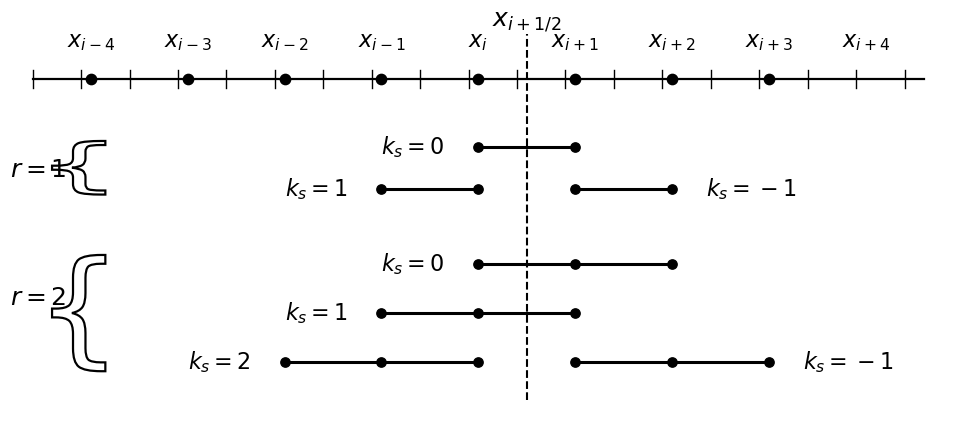

In [ ]:
#!/usr/bin/env python3
"""
recreate_stencil_figure_textpath.py

Improvements vs prior version:
- Uses matplotlib.textpath.TextPath + PathPatch to draw scalable braces (instead of a "{"
  text glyph). This makes placement/size consistent and publication-like.
- Ensures dots sit exactly on the number line and on each stencil line (same y as line).
- Keeps everything black/white.

Tweak knobs:
- figsize, font sizes, line widths, marker sizes
- brace geometry: brace_width, brace_x_offset
- row y-positions for r=1 and r=2
"""

from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt

from matplotlib.textpath import TextPath
from matplotlib.patches import PathPatch
from matplotlib.transforms import Affine2D


# ----------------------------
# Drawing helpers
# ----------------------------
def add_brace(
    ax,
    x: float,
    y0: float,
    y1: float,
    width: float = 0.55,
    side: str = "left",
    lw: float = 1.6,
    color: str = "k",
):
    """
    Draw a scalable curly brace spanning [y0, y1] at x using TextPath + PathPatch.

    Parameters
    ----------
    x      : x location of brace "spine"
    y0,y1  : vertical span
    width  : approximate brace width in data-units
    side   : "left" or "right"
    lw     : stroke width
    """
    if y1 < y0:
        y0, y1 = y1, y0

    glyph = "{" if side == "left" else "}"
    tp = TextPath((0, 0), glyph, size=1)  # unit-ish glyph path in font units

    # Bounding box in its own coordinates
    bb = tp.get_extents()
    glyph_w = bb.width
    glyph_h = bb.height

    target_h = (y1 - y0)
    # Scale glyph to match target height (and then width by an independent factor)
    sy = target_h / glyph_h
    sx = width / glyph_w

    # After scaling, position brace so it spans y0..y1 and is centered in x.
    # We'll align the glyph's bbox min corner to (0,0) first, then scale, then translate.
    to_origin = Affine2D().translate(-bb.x0, -bb.y0)
    scale = Affine2D().scale(sx, sy)

    # Compute final bbox after origin+scale to place nicely
    bb_scaled = scale.transform_bbox(to_origin.transform_bbox(bb))
    # Center brace in y, and place around x
    # For "left" brace, we typically want its rightmost edge near x.
    if side == "left":
        tx = x - bb_scaled.x1
    else:
        tx = x - bb_scaled.x0

    ty = y0  # because we scaled from y0 baseline after origin shift

    trans = to_origin + scale + Affine2D().translate(tx, ty)

    patch = PathPatch(tp, transform=trans + ax.transData, fill=False, lw=lw, edgecolor=color)
    ax.add_patch(patch)
    return patch


def draw_number_line(
    ax,
    y: float,
    x0: float,
    x1: float,
    tick_positions: np.ndarray,
    node_positions: np.ndarray,
    tick_len: float = 0.12,
    line_lw: float = 1.6,
    tick_lw: float = 1.0,
    node_s: float = 55,
):
    """Draw a number line at y with ticks and nodes that sit exactly on the line."""
    ax.plot([x0, x1], [y, y], lw=line_lw, color="k", zorder=1)

    for x in tick_positions:
        ax.plot([x, x], [y - tick_len, y + tick_len], lw=tick_lw, color="k", zorder=1)

    
    # Dots centered ON the line (same y)
    ax.scatter(node_positions, np.full_like(node_positions, y, dtype=float),
               s=node_s, color="k", zorder=3)


def segment(
    ax,
    y: float,
    x0: float,
    x1: float,
    dots: np.ndarray,
    label: str | None = None,
    label_pos: str = "left",
    line_lw: float = 2.2,
    dot_s: float = 45,
    label_fs: float = 16,
    label_dx: float = 0.35,
):
    """Draw a stencil segment line and dots ON the line."""
    ax.plot([x0, x1], [y, y], lw=line_lw, color="k", zorder=2)
    ax.scatter(dots, np.full_like(dots, y, dtype=float), s=dot_s, color="k", zorder=3)

    if label is not None:
        if label_pos == "left":
            ax.text(x0 - label_dx, y, label, ha="right", va="center", fontsize=label_fs, color="k")
        elif label_pos == "right":
            ax.text(x1 + label_dx, y, label, ha="left", va="center", fontsize=label_fs, color="k")
        else:
            ax.text((x0 + x1) / 2, y + 0.25, label, ha="center", va="bottom", fontsize=label_fs, color="k")


def make_figure(
    out_path="recreated_stencil_figure.png",
    figsize=(12, 5),
):
    fig, ax = plt.subplots(figsize=figsize)

    # Canvas extents (data coordinates)
    ax.set_xlim(-4.8, 4.8)
    ax.set_ylim(-3.2, 1.9)
    ax.axis("off")

    # ----------------------------
    # Top number line
    # ----------------------------
    y_top = 1.25
    x_left, x_right = -4.6, 4.6

    tick_step = 0.5
    tick_positions = np.arange(x_left, x_right + 1e-12, tick_step)
    node_positions = np.arange(-4, 5, 1)

    draw_number_line(
        ax,
        y=y_top,
        x0=x_left,
        x1=x_right,
        tick_positions=tick_positions,
        node_positions=node_positions,
        tick_len=0.12,
        line_lw=1.6,
        tick_lw=1.0,
        node_s=55,
    )

    # labels x_{i+k}
    for k, x in zip(range(-4, 5), node_positions):
        if k == 0:
            lbl = r"$x_i$"
        elif k < 0:
            lbl = rf"$x_{{i{k}}}$"    # e.g. x_{i-2}
        else:
            lbl = rf"$x_{{i+{k}}}$"  # e.g. x_{i+3}
        ax.text(x, y_top + 0.35, lbl, ha="center", va="bottom", fontsize=16, color="k")

    # dashed interface at x_{i+1/2}
    x_half = 0.5
    ax.plot([x_half, x_half], [-3.0, 1.85], ls="--", lw=1.5, color="k", zorder=1)
    ax.text(x_half, y_top + 0.6, r"$x_{i+1/2}$", ha="center", va="bottom", fontsize=18, color="k")

    # ----------------------------
    # r = 1 group
    # ----------------------------
    y_r1_mid = 0.05
    ax.text(-4.25, y_r1_mid, r"$r=1$", fontsize=18, ha="right", va="center", color="k")

    # brace span for r=1 rows
    # (make it span from top r=1 row to bottom r=1 row)
    y_r1_top = 0.35
    y_r1_bot = -0.2
    brace_x = -3.85
    add_brace(ax, x=brace_x, y0=y_r1_bot - 0.08, y1=y_r1_top + 0.08, width=0.55, side="left", lw=1.6)

    segment(ax, y=y_r1_top, x0=0.0,  x1=1.0, dots=np.array([0, 1]),   label=r"$k_s=0$",  label_pos="left")
    segment(ax, y=y_r1_bot, x0=-1.0, x1=0.0, dots=np.array([-1, 0]),  label=r"$k_s=1$",  label_pos="left")
    segment(ax, y=y_r1_bot, x0=1.0,  x1=2.0, dots=np.array([1, 2]),   label=r"$k_s=-1$", label_pos="right")

    # ----------------------------
    # r = 2 group
    # ----------------------------
    y_r2_mid = -1.65
    ax.text(-4.25, y_r2_mid, r"$r=2$", fontsize=18, ha="right", va="center", color="k")

    y_r2_0  = -1.2
    y_r2_1  = -1.85
    y_r2_2  = -2.5

    add_brace(ax, x=brace_x, y0=y_r2_2 - 0.12, y1=y_r2_0 + 0.12, width=0.55, side="left", lw=1.6)

    segment(ax, y=y_r2_0, x0=0.0,  x1=2.0, dots=np.array([0, 1, 2]),     label=r"$k_s=0$",  label_pos="left")
    segment(ax, y=y_r2_1, x0=-1.0, x1=1.0, dots=np.array([-1, 0, 1]),    label=r"$k_s=1$",  label_pos="left")
    segment(ax, y=y_r2_2, x0=-2.0, x1=0.0, dots=np.array([-2, -1, 0]),   label=r"$k_s=2$",  label_pos="left")
    segment(ax, y=y_r2_2, x0=1.0,  x1=3.0, dots=np.array([1, 2, 3]),     label=r"$k_s=-1$", label_pos="right")

    # Save
    #plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()


if __name__ == "__main__":
    make_figure(out_path="recreated_stencil_figure.png", figsize=(12, 5))